<a href="https://colab.research.google.com/github/brindha22001-wq/Brindha-D/blob/main/Same_Time_Series_LSTM_Implementation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [ ]:
content ='/content/IPG2211A2N - IPG2211A2N.csv'
data1 =pd.read_csv(content)
print(data.head())

         DATE  IPG2211A2N
0  1939-01-01      3.3842
1  1939-02-01      3.4100
2  1939-03-01      3.4875
3  1939-04-01      3.5133
4  1939-05-01      3.5133


In [ ]:
data1.shape

(981, 2)

In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        981 non-null    object 
 1   IPG2211A2N  981 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.5+ KB


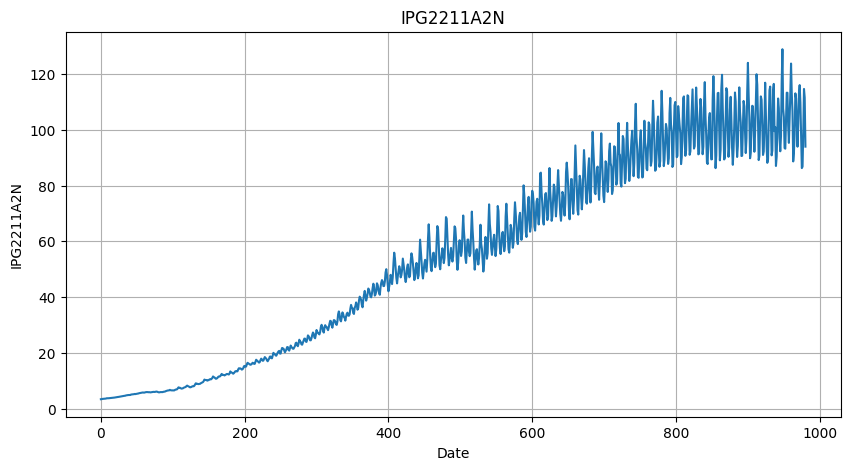

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data1['IPG2211A2N'])
plt.title('IPG2211A2N')
plt.xlabel('Date')
plt.ylabel('IPG2211A2N')
plt.grid(True)
plt.show()

In [ ]:
#Preprocessing the data now:
scale=MinMaxScaler(feature_range=(0,1))
data1_scaled=scale.fit_transform(np.array(data1['IPG2211A2N']).reshape(-1,1))

In [ ]:
#Create the sequences:

X=[]
Y=[]
window_size=60
for i in range(60,data1_scaled.shape[0]):
  X.append(data1_scaled[i-60:i,0])
  Y.append(data1_scaled[i,0])
X = np.array(X)
Y = np.array(Y)
print(X.shape)



(921, 60)


In [ ]:
from keras.src.models import model
from keras.layers import Bidirectional
model = Sequential()
model.add(LSTM(units=50, input_shape=(X.shape[1], 1))) # return_sequences=False by default
model.add(Dense(units=1)) # Add a Dense layer to output a single value
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, Y, epochs=100, batch_size=32)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0692
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0043
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0024
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0026
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0026
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0028
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0026
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0023
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0026
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0025
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0025
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023
Epoch 13/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0028
Epoch 14/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0024
Epoch 15/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0024
E

In [ ]:
#Make Predictions now:

y_pred = model.predict(X)
y_pred = scale.inverse_transform(y_pred)
y_test = scale.inverse_transform(Y.reshape(-1, 1))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


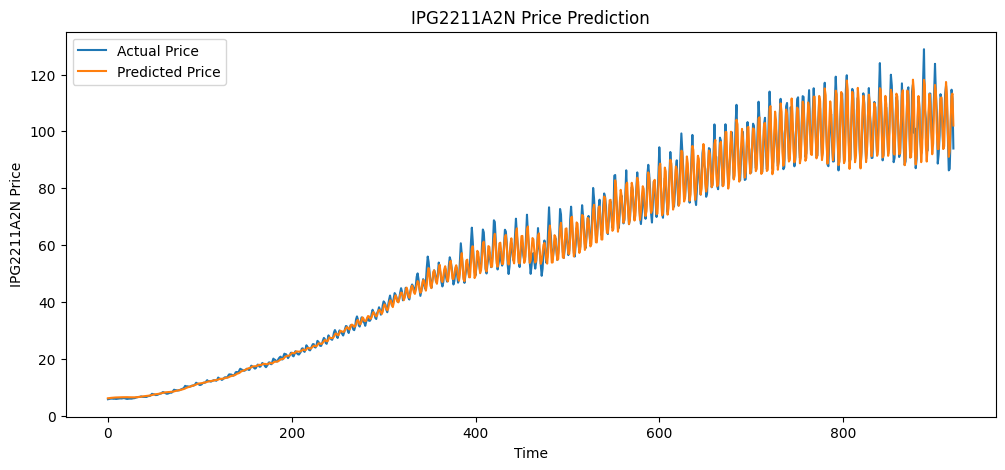

In [ ]:
#VIsualize Results:
plt.figure(figsize=(12,5))
plt.plot(y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title('IPG2211A2N Price Prediction')
plt.xlabel('Time')
plt.ylabel('IPG2211A2N Price')
plt.legend()
plt.show()
#So we could see that the plot has some trend thus it is an Unstationary value has been predicted.

